## 0. Imports, Setup

We created specific utils file for each part of the project.

In [1]:
import sys
import os
import pickle
import pandas as pd

from sklearn.model_selection import train_test_split

SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from text_mining_utils import (
    LABEL_MAP,
    RANDOM_STATE,
    make_split,
    preprocess_pipeline,
    evaluate_model,
    plot_model_confusion_matrix,
    detect_transformer_device,
    run_transformer_encoder_experiment,
    # EDA helpers
    plot_class_distribution, plot_tweet_length_distribution,
    plot_wordclouds, plot_top_tokens, show_preprocessing_examples,
)

DATA_DIR  = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

TM_SPLIT_RAW_PATH         = os.path.join(DATA_DIR, "tm_split_raw.pkl")
TM_SPLIT_CLASSICAL_PATH   = os.path.join(DATA_DIR, "tm_split_classical.pkl")
TM_SPLIT_TRANSFORMER_PATH = os.path.join(DATA_DIR, "tm_split_transformer.pkl")
EMBEDDING_CACHE_DIR       = os.path.join(DATA_DIR, "transformer_cache")
os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

# Load the datasets
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

## 1. Data Exploration


In [2]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [3]:
(train_df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

label
0    15.11
1    20.15
2    64.74
Name: proportion, dtype: float64

In [4]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


### 1.2 Class Distribution

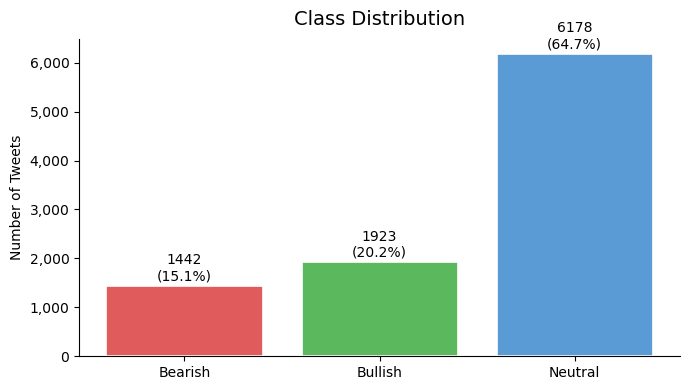

In [5]:
plot_class_distribution(train_df, label_col="label")

The majority of the dataset has as label "Neutral", showing great class imbalacement.

### 1.3 Tweet Length Distribution

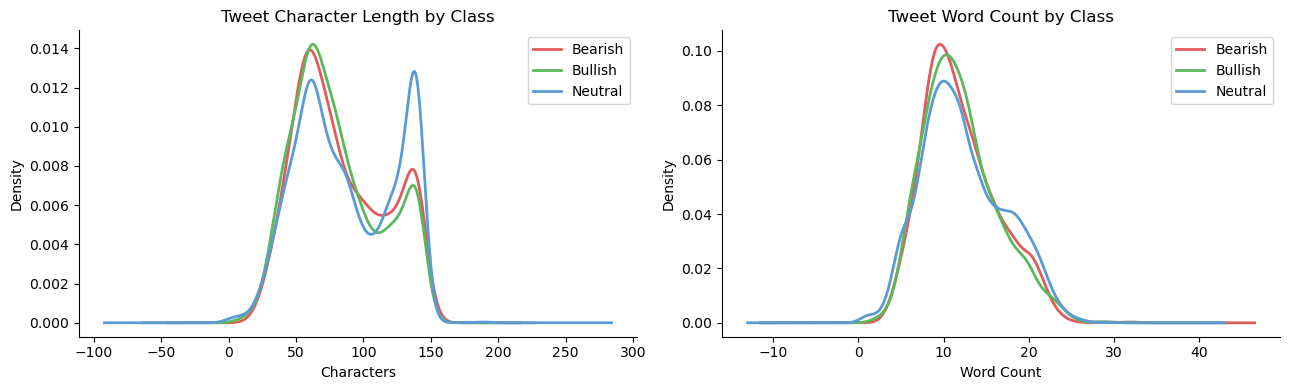

In [6]:
plot_tweet_length_distribution(train_df, text_col="text", label_col="label")

In [7]:
# Summary stats per class
train_df["char_len"]  = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df.groupby("label")[["char_len", "word_count"]].describe().round(1)

char_len                                             word_count        \
         count  mean   std   min   25%   50%    75%    max      count  mean   
label                                                                         
0       1442.0  83.4  33.0  20.0  57.2  75.5  111.0  151.0     1442.0  12.0   
1       1923.0  80.4  32.4   9.0  57.0  74.0  103.0  154.0     1923.0  11.9   
2       6178.0  88.1  36.2   2.0  59.0  82.0  125.0  190.0     6178.0  12.3   

                                        
       std  min  25%   50%   75%   max  
label                                   
0      4.3  3.0  9.0  11.0  15.0  32.0  
1      4.3  2.0  9.0  11.0  14.0  29.0  
2      4.8  1.0  9.0  12.0  16.0  29.0

We conclude that does not exist a difference between the tweet sizes and the label.

### 1.4 Word Clouds per Class

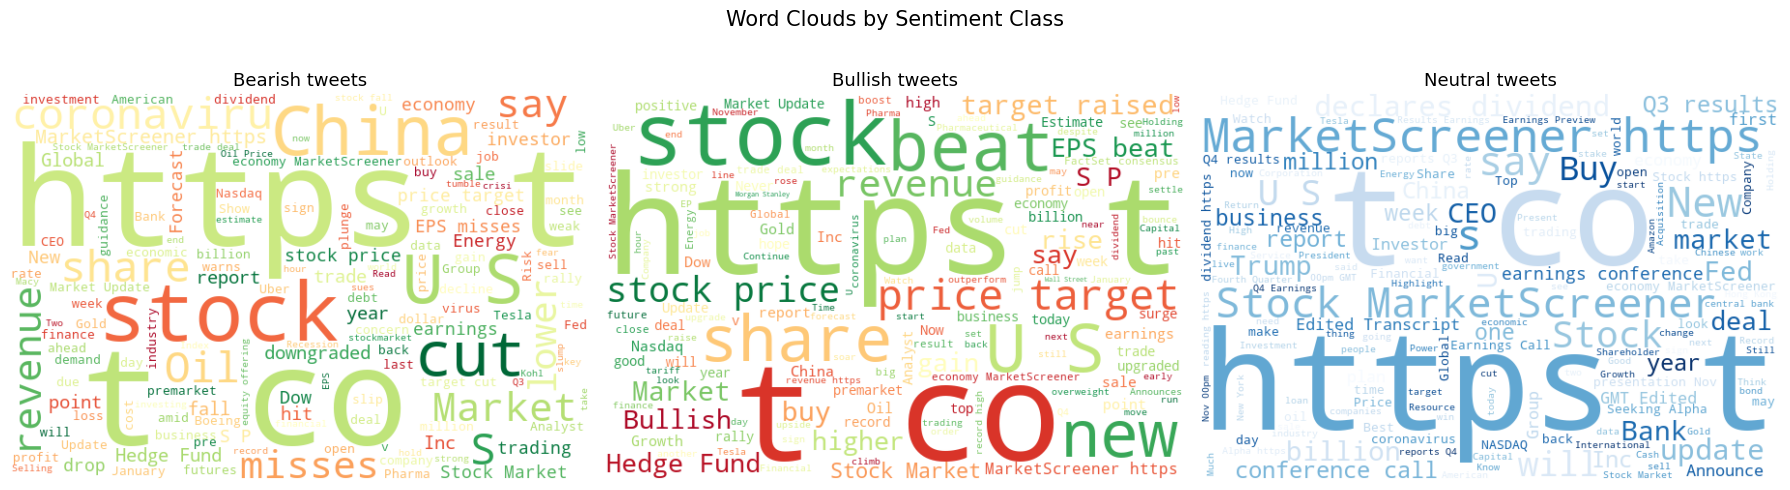

In [8]:
plot_wordclouds(train_df, text_col="text", label_col="label")

From the word clouds before preprocessing, frequent tokens are still dominated by noisy market syntax (tickers, short boilerplate fragments, and repeated symbols). This motivates the use of stronger normalization before feature extraction.

### 1.5 Top Tokens per Class (before preprocessing)

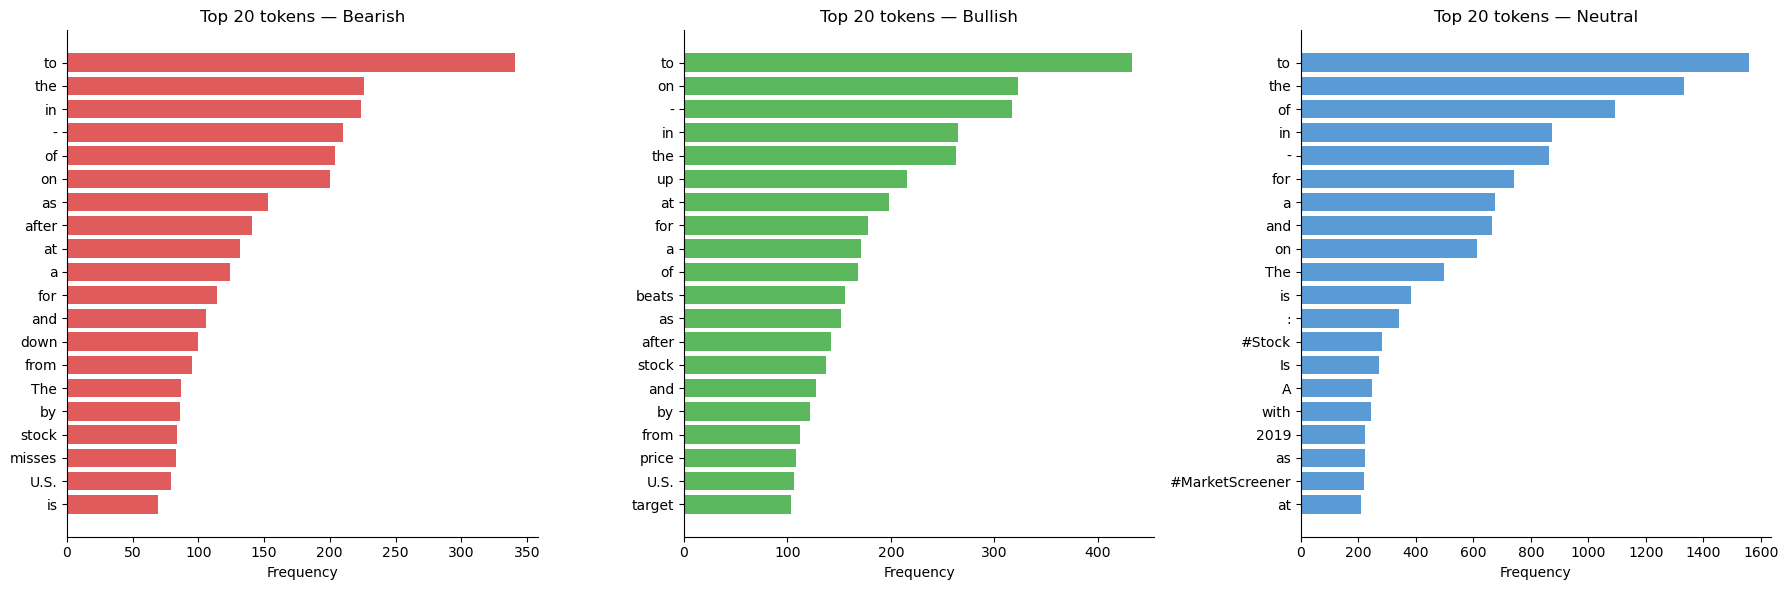

In [9]:
plot_top_tokens(train_df, text_col="text", label_col="label", n=20)

## 2. Data Preprocessing

The preprocessing logic is now mode-based in `preprocess_pipeline` (from `text_mining_utils.py`), with two clear routes depending on the modeling approach.

### Available modes
1. `mode="classical"` (for BoW / TF-IDF / Word2Vec style pipelines)
   - Regex noise removal
   - Tokenization (TweetTokenizer)
   - Stop word removal
   - POS-aware lemmatization

2. `mode="transformer"` (for Transformer Encoder models)
   - Lightweight normalization with placeholder tokens
   - Examples: `[URL]`, `[USER]`, `[CASHTAG]`, `[HASHTAG]`, `[RT]`
   - Keeps richer context for model tokenizers, instead of aggressive token filtering

This keeps one unified API while matching best practices for classical NLP vs transformer workflows.

### 2.1 Before / After Examples - Classical Mode

In [10]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,nokia stock price target raise mkm partner
1,Russia backs OPEC+ oil output cuts,russia back opec oil output cut
2,Many workers don't have access to retirement s...,many worker access retirement saving program e...
3,About 200 Google employees demonstrated outsid...,google employee demonstrate outside company sa...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,idg energy investment voluntary announcement i...
5,Vans parent VF Corp. says 60% of China stores ...,van parent vf corp say china store close coron...
6,AU Optronics reports Q4 results,au optronics report q result
7,$KZR Kezar Life Sciences Highlights Therapeuti...,kezar life science highlight therapeutic poten...
8,U.S. Oil Inventories Rise More Than Expected #...,u oil inventory rise expect wti stock marketsc...
9,A Big Step Forward For the Treatment of ALS,big step forward treatment al


### 2.2 Before / After Examples - Transformer Mode

In [11]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline, mode = "transformer"
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,Nokia stock price target raised to $6.00 from ...
1,Russia backs OPEC+ oil output cuts,Russia backs OPEC+ oil output cuts
2,Many workers don't have access to retirement s...,Many workers don't have access to retirement s...
3,About 200 Google employees demonstrated outsid...,About 200 Google employees demonstrated outsid...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...
5,Vans parent VF Corp. says 60% of China stores ...,Vans parent VF Corp. says 60% of China stores ...
6,AU Optronics reports Q4 results,AU Optronics reports Q4 results
7,$KZR Kezar Life Sciences Highlights Therapeuti...,[CASHTAG] Kezar Life Sciences Highlights Thera...
8,U.S. Oil Inventories Rise More Than Expected #...,U.S. Oil Inventories Rise More Than Expected [...
9,A Big Step Forward For the Treatment of ALS,A Big Step Forward For the Treatment of ALS


### 2.3 Top Tokens After Preprocessing

Compare the top tokens before and after — confirms noise removal and stop word filtering worked.

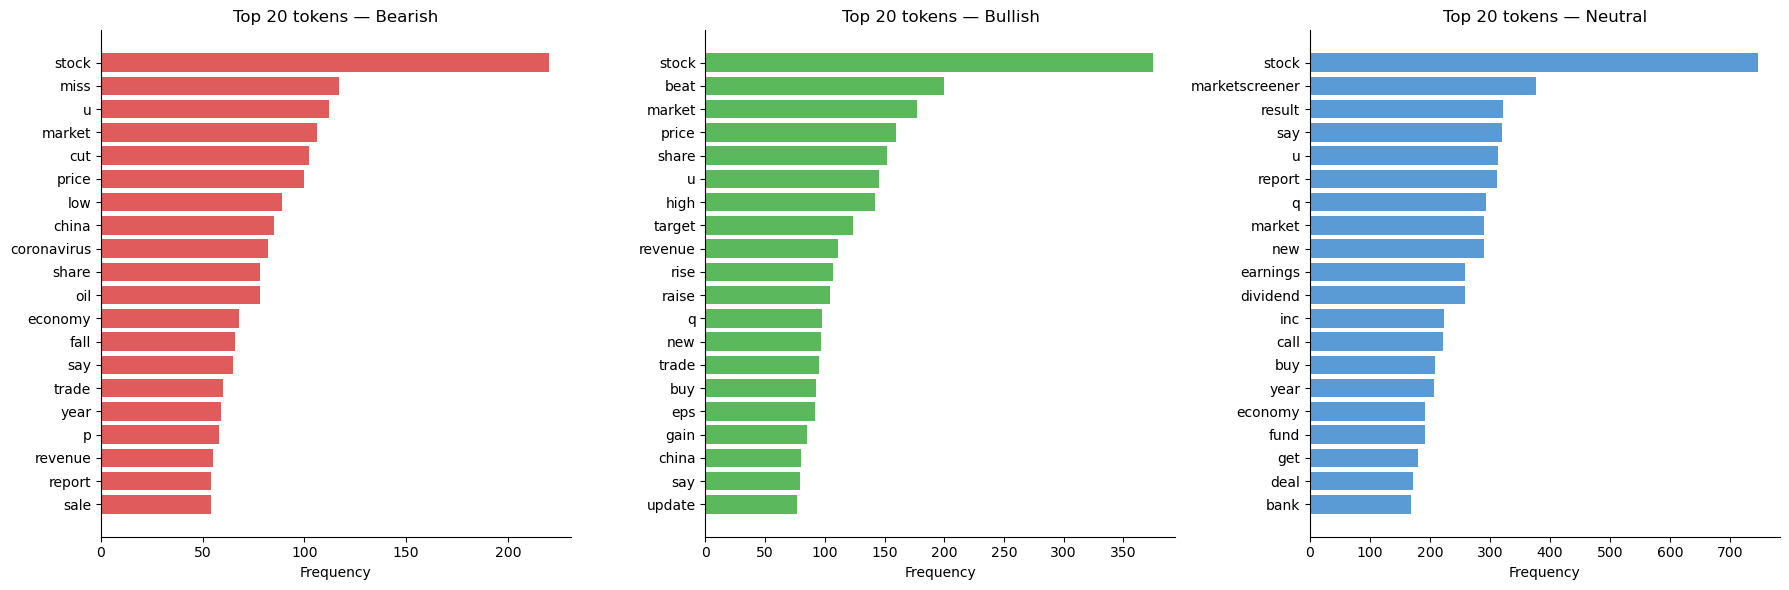

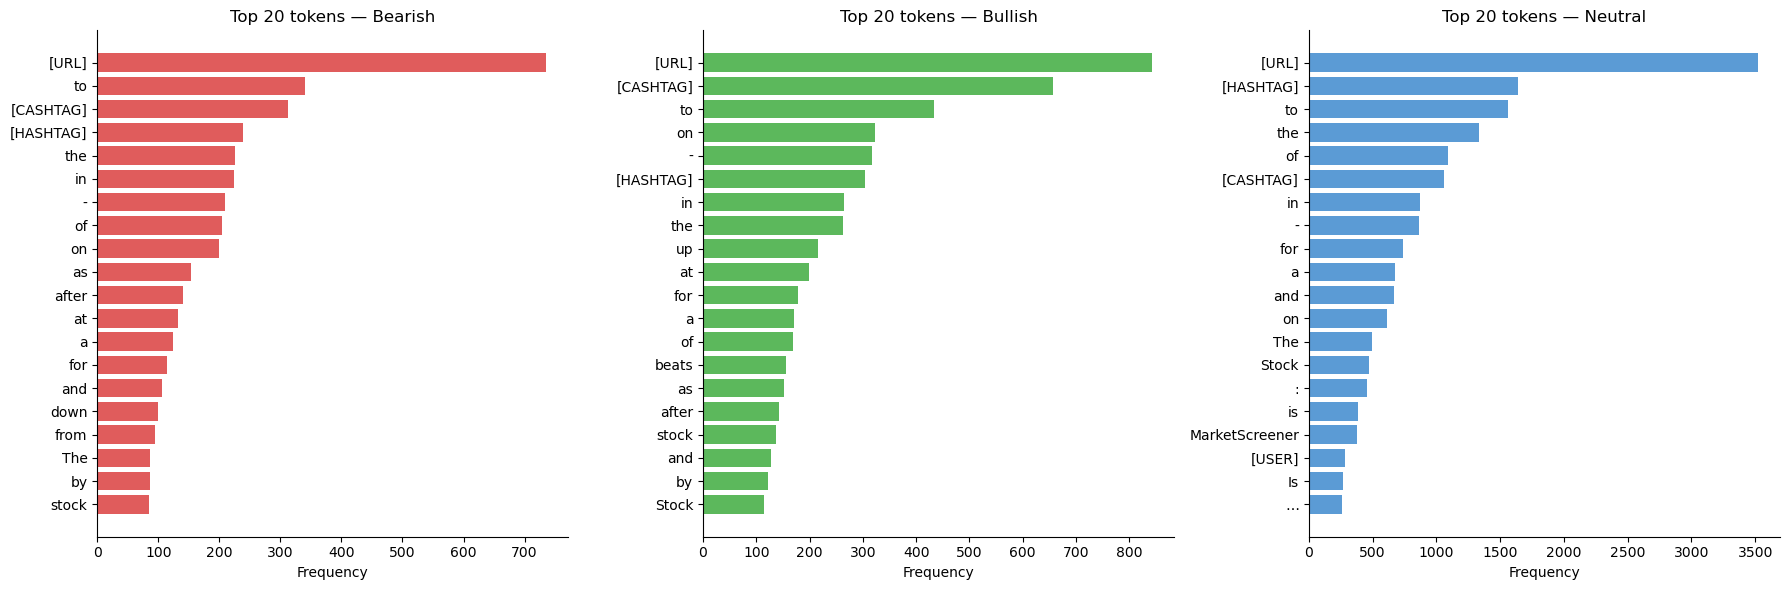

In [12]:
# Build a temporary df with preprocessed text for the full train set (for visualization only)
train_df["text_classical"] = preprocess_pipeline(train_df["text"])
train_df["text_transformer"] = preprocess_pipeline(train_df["text"], mode="transformer")

plot_top_tokens(train_df, text_col="text_classical", label_col="label", n=20)
plot_top_tokens(train_df, text_col="text_transformer", label_col="label", n=20)

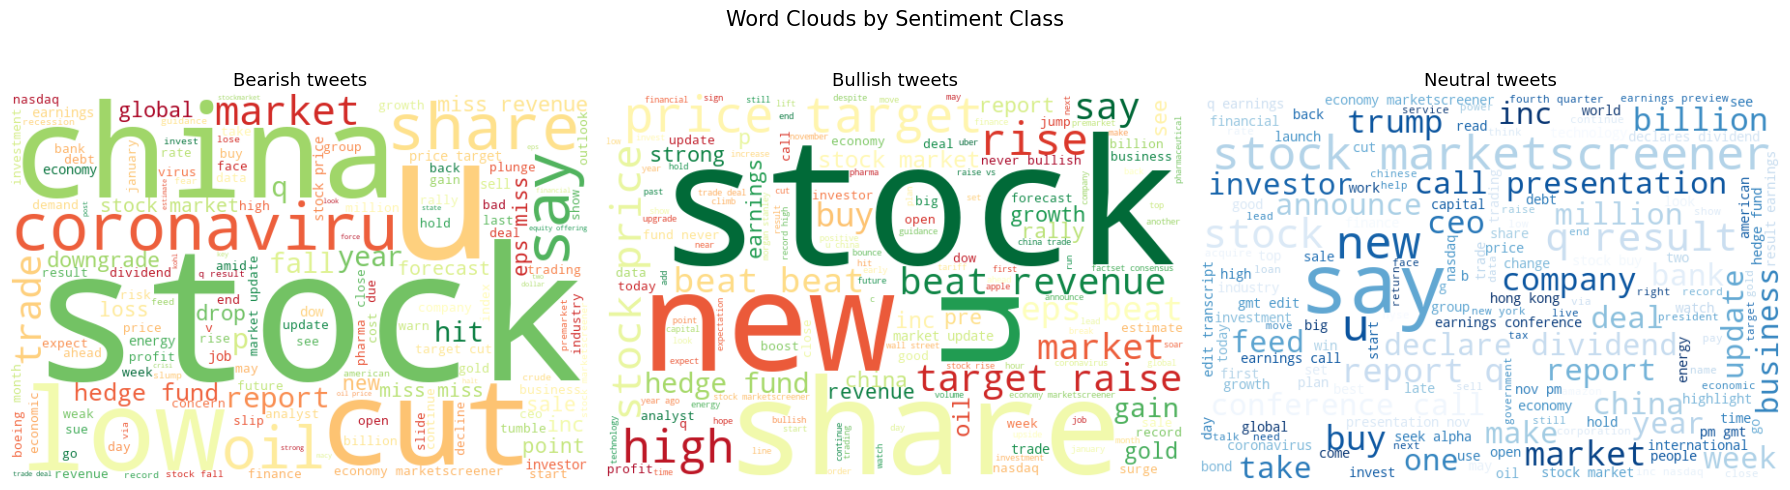

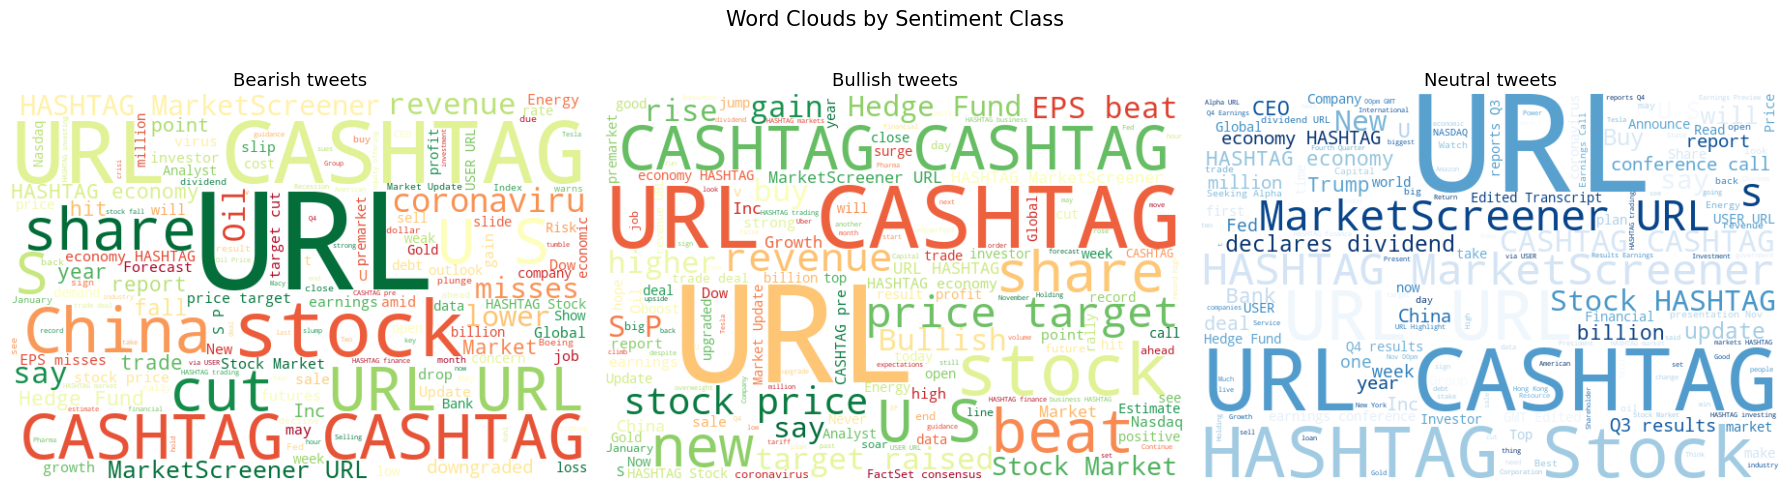

In [13]:
# Word clouds after preprocessing
plot_wordclouds(train_df, text_col="text_classical", label_col="label")
plot_wordclouds(train_df, text_col="text_transformer", label_col="label")

Preprocessing results are consistent with the intended behavior of both routes:
- Classical mode highlights cleaner semantic tokens useful for traditional vectorizers.
- Transformer mode preserves contextual cues through placeholder tokens such as `[URL]`, `[USER]`, and `[CASHTAG]`, which can help downstream transformer tokenizers retain structure.

# 3. Data Split

### 3.1 Shared Train / Validation Split

We keep one stratified split and derive two text views from it:
- `classical`: lemmatized text for BoW / TF-IDF / Word2Vec experiments.
- `transformer`: lightweight normalization for encoder-based models.

### 3.2 Build and Save the Three Text Views

In [14]:
raw_split = make_split(
    train_df,
    text_col="text",
    label_col="label",
    test_size=0.2,
    save_path=TM_SPLIT_RAW_PATH,
)

X_train_raw = raw_split["X_train"]
X_val_raw   = raw_split["X_val"]
y_train     = raw_split["y_train"]
y_val       = raw_split["y_val"]

X_train_classical = preprocess_pipeline(X_train_raw, mode="classical")
X_val_classical   = preprocess_pipeline(X_val_raw, mode="classical")

X_train_transformer = preprocess_pipeline(X_train_raw, mode="transformer")
X_val_transformer   = preprocess_pipeline(X_val_raw, mode="transformer")

with open(TM_SPLIT_CLASSICAL_PATH, "wb") as f:
    pickle.dump(
        {
            "X_train": X_train_classical,
            "X_val": X_val_classical,
            "y_train": y_train,
            "y_val": y_val,
        },
        f,
    )

with open(TM_SPLIT_TRANSFORMER_PATH, "wb") as f:
    pickle.dump(
        {
            "X_train": X_train_transformer,
            "X_val": X_val_transformer,
            "y_train": y_train,
            "y_val": y_val,
        },
        f,
    )

print(f"Saved raw split         -> {TM_SPLIT_RAW_PATH}")
print(f"Saved classical split   -> {TM_SPLIT_CLASSICAL_PATH}")
print(f"Saved transformer split -> {TM_SPLIT_TRANSFORMER_PATH}")

Train size      : 7634 samples
Validation size : 1909 samples
Split saved to  : c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_raw.pkl
Saved raw split         -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_raw.pkl
Saved classical split   -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_classical.pkl
Saved transformer split -> c:\Users\joaop\master\text mining\text_mining_project\data\tm_split_transformer.pkl


In [15]:
pd.DataFrame(
    {
        "raw": X_train_raw.head(3).to_list(),
        "classical": X_train_classical.head(3).to_list(),
        "transformer": X_train_transformer.head(3).to_list(),
        "label": y_train.head(3).to_list(),
    }
)

,raw,classical,transformer,label
0,"Container Service Returning To Portland, Oregon",container service return portland oregon,"Container Service Returning To Portland, Oregon",2
1,Japan Tobacco reports FY results,japan tobacco report fy result,Japan Tobacco reports FY results,2
2,$OPK squeeze into the close !!!! $INPX strong...,squeeze close strong close,[CASHTAG] squeeze into the close !!!! [CASHTAG...,1


# 4. Feature Engineering

### 4.1 Transformer Encoder Features

Following the same idea used in Lab 4, we convert each tweet into a dense vector with a Hugging Face encoder and then feed those vectors into a simple classifier.

In [ ]:
TRANSFORMER_MODELS = {
    "DistilBERT Encoder + Logistic Regression": "distilbert-base-uncased",
    "Twitter RoBERTa Encoder + Logistic Regression": "cardiffnlp/twitter-roberta-base",
}

BATCH_SIZE = 16
MAX_LENGTH = 96
TRAIN_LIMIT = None 
VAL_LIMIT = None    

device, device_name = detect_transformer_device()

X_train_tf_exp = X_train_transformer.copy()
y_train_tf_exp = y_train.copy()
X_val_tf_exp = X_val_transformer.copy()
y_val_tf_exp = y_val.copy()

if TRAIN_LIMIT is not None and len(X_train_tf_exp) > TRAIN_LIMIT:
    X_train_tf_exp, _, y_train_tf_exp, _ = train_test_split(
        X_train_tf_exp,
        y_train_tf_exp,
        train_size=TRAIN_LIMIT,
        stratify=y_train_tf_exp,
        random_state=RANDOM_STATE,
    )

if VAL_LIMIT is not None and len(X_val_tf_exp) > VAL_LIMIT:
    X_val_tf_exp, _, y_val_tf_exp, _ = train_test_split(
        X_val_tf_exp,
        y_val_tf_exp,
        train_size=VAL_LIMIT,
        stratify=y_val_tf_exp,
        random_state=RANDOM_STATE,
    )

print(f"Using device: {device_name}")
print(f"Training tweets: {len(X_train_tf_exp):,}")
print(f"Validation tweets: {len(X_val_tf_exp):,}")

Using device: cpu
Training tweets: 7,634
Validation tweets: 1,909


# 5. Classification Models

For the Transformer Encoder part of the assignment, we test two encoder variations using exactly the same downstream classifier:
- DistilBERT encoder + Logistic Regression
- Twitter RoBERTa encoder + Logistic Regression

In [18]:
transformer_runs = {}
transformer_metrics = []

for experiment_name, checkpoint in TRANSFORMER_MODELS.items():
    result = run_transformer_encoder_experiment(
        experiment_name=experiment_name,
        model_checkpoint=checkpoint,
        X_train_text=X_train_tf_exp,
        y_train_labels=y_train_tf_exp,
        X_val_text=X_val_tf_exp,
        y_val_labels=y_val_tf_exp,
        cache_dir=EMBEDDING_CACHE_DIR,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH,
        device=device,
    )
    transformer_runs[experiment_name] = result
    transformer_metrics.append(result["metrics"])

transformer_results_df = (
    pd.DataFrame(transformer_metrics)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
transformer_results_df

Loaded cached train embeddings from c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\train_distilbert_base_uncased_n7634_l96.pkl
Loaded cached validation embeddings from c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\val_distilbert_base_uncased_n1909_l96.pkl

DistilBERT Encoder + Logistic Regression
              precision    recall  f1-score   support

     Bearish       0.50      0.69      0.58       288
     Bullish       0.61      0.74      0.67       385
     Neutral       0.91      0.76      0.83      1236

    accuracy                           0.75      1909
   macro avg       0.67      0.73      0.69      1909
weighted avg       0.78      0.75      0.76      1909

Loaded cached train embeddings from c:\Users\joaop\master\text mining\text_mining_project\data\transformer_cache\train_cardiffnlp__twitter_roberta_base_n7634_l96.pkl
Loaded cached validation embeddings from c:\Users\joaop\master\text mining\text_mining_project

,model,accuracy,precision,recall,f1_macro
0,Twitter RoBERTa Encoder + Logistic Regression,0.7852,0.7143,0.7757,0.7366
1,DistilBERT Encoder + Logistic Regression,0.7486,0.6716,0.7316,0.6926


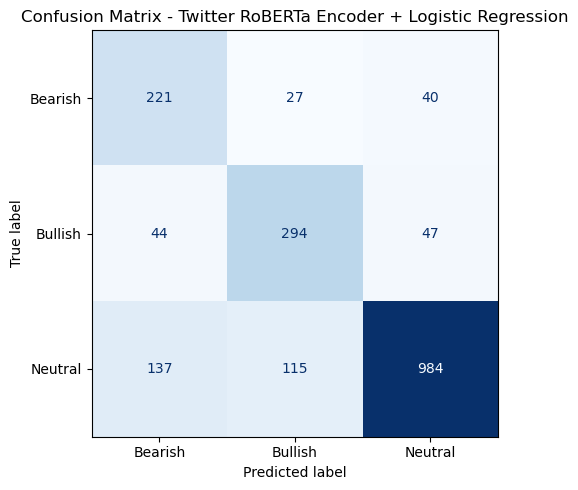

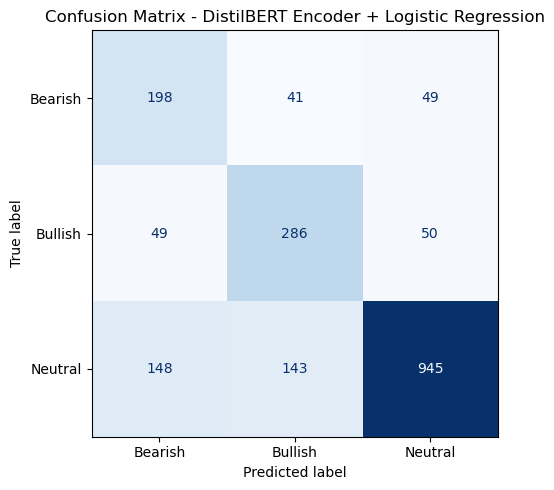

In [19]:
for experiment_name in transformer_results_df["model"]:
    plot_model_confusion_matrix(
        y_val_tf_exp,
        transformer_runs[experiment_name]["predictions"],
        model_name=experiment_name,
    )